<a href="https://colab.research.google.com/github/itseriqq/natural-language-processing/blob/main/Unificado_Projeto_Pr%C3%A1tico_PLN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Processamento de Linguagem Natural [2025-Q3]**
Prof. Alexandre Donizeti Alves

### **PROJETO PRÁTICO** [LangChain + Grandes Modelos de Linguagem]


O **PROJETO PRÁTICO** deve ser feito utilizando o **Google Colab** com uma conta sua vinculada ao Gmail. O link do seu notebook armazenado no Google Drive e o link de um repositório no GitHub devem ser enviados usando o seguinte formulário:

> https://forms.gle/D4gLqP1iGgyn2hbH8


**IMPORTANTE**: A submissão deve ser feita até o dia **07/12 (domingo)** APENAS POR UM INTEGRANTE DA EQUIPE, até às 23h59. Por favor, lembre-se de dar permissão de ACESSO IRRESTRITO para o professor da disciplina.

### **EQUIPE**

---

**POR FAVOR, PREENCHER OS INTEGRANDES DA SUA EQUIPE:**


**Integrante 01:**

`Erick Augusto Silva Pereira - RA: 11202130310`

**Integrante 02:**

`Victor Ravazio de Lima - RA: 11201920941`

### **GRANDE MODELO DE LINGUAGEM (*Large Language Model - LLM*)**

---

Cada equipe deve selecionar um Grande Modelo de Linguagem (*Large Language Model - LMM*).



Por favor, informe os dados do LLM selecionada:

>


**LLM**: Gemini (Modelo Flash)

>

**Link para a documentação oficial**: https://ai.google.dev/gemini-api/docs/



### **API (Opcional)**
---

Por favor, informe os dados da API selecionada:

**API**: TwitterApi.io

**Site oficial**: https://twitterapi.io/

**Link para a documentação oficial**: https://docs.twitterapi.io/introduction






### **DESCRIÇÃO**
---

Implementar um `notebook` no `Google Colab` que faça uso do framework **`LangChain`** (obrigatório) e de um **LLM** aplicando, no mínimo, DUAS técnicas de PLN. As técnicas podem ser aplicada em qualquer córpus obtido a partir de uma **API** ou a partir de uma página Web.

O **LLM** e a **API** selecionados devem ser informados na seguinte planilha:

> https://docs.google.com/spreadsheets/d/1iIUZcwnywO7RuF6VEJ8Rx9NDT1cwteyvsnkhYr0NWtU/edit?usp=sharing

>
As seguintes técnicas de PLN podem ser usadas:

*   Correção Gramatical
*   Classificação de Textos
*   **Análise de Sentimentos**
*   **Detecção de Emoções**
*   **Extração de Palavras-chave**
*   Tradução de Textos
*   Sumarização de Textos
*   Similaridade de Textos
*   Reconhecimento de Entidades Nomeadas
*   Sistemas de Perguntas e Respostas
>

**IMPORTANTE:** É obrigatório usar o e-mail da UFABC.


### **CRITÉRIOS DE AVALIAÇÃO**
---


Serão considerados como critérios de avaliação os seguintes pontos:

* Uso do framework **`LangChain`**.

* Escolha e uso de um **LLM**.

* Escolha e uso de uma **API** ou **Página Web**.

* Projeto disponível no Github.

* Apresentação (5 a 10 minutos).

* Criatividade no uso do framework **`LangChain`** em conjunto com o **LLM** e a **API**.




**IMPORTANTE**: todo o código do notebook deve ser executado. Código sem execução não será considerado.

### **IMPLEMENTAÇÃO**
---

# Capturando as respostas de tweets com TwitterAPI

Vamos utilizar a TwitterAPI para coletar as respostas do tweet especificado e salva-lás em um array de textos, salvando também em um arquivo .json para utilizar posteriormente e evitar consultas desnecessárias.

In [ ]:
#@title Inicializando

import requests
import time
import json
from google.colab import userdata

api_key = userdata.get('twitterApi2')

headers = {
    'X-API-Key': api_key,
    'Accept': 'application/json',
}

In [ ]:
#@title Função de captura de respostas na API

def capturar_respostas(tweet_id, lista, page_count = 0, cursor = "", max_pages=2):
  while page_count < max_pages:
    # monta URL incluindo cursor (query param para buscar mais dados) só se não for vazio
    if cursor:
        url = f'https://api.twitterapi.io/twitter/tweet/replies?tweetId={tweet_id}&cursor={cursor}'
    else:
        url = f'https://api.twitterapi.io/twitter/tweet/replies?tweetId={tweet_id}'

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print(f'Erro {response.status_code}: {response.text}')
        break

    data = response.json()
    tweets = data.get("tweets", [])
    textos = [tweet["text"] for tweet in tweets]
    lista.extend(textos)

    page_count += 1

    if data.get("has_next_page", False):
        cursor = data.get("next_cursor", "")
        time.sleep(6)  # aguarda 6 segundos antes da próxima requisição para burlar os 5 segundos de api limit q eles tem
    else:
        break

In [ ]:
#@title Função que salva as respostas em um arquivo .json

def salvar_json(lista, sufixo=""):
    # Monta o nome do arquivo dinamicamente
    filename = f"replies_{sufixo}.json" if sufixo else "replies.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(lista, f, ensure_ascii=False, indent=2)

In [ ]:
#@title Carregando o conteúdo de um arquivo .json na lista

def carregar_json(lista, sufixo=""):
    filename = f"replies_{sufixo}.json" if sufixo else "replies.json"
    with open(filename, "r", encoding="utf-8") as f:
        dados = json.load(f)
    lista.extend(dados)

In [ ]:
#@title Função que imprime os tweets da lista
def imprimir_lista(lista):
  print(f"Quantidade total de tweets: {len(lista)}")
  for i, texto in enumerate(lista, 1):
      print(f"Tweet {i}: {texto}\n")

In [ ]:
#@title Definição das listas e tweetsIds que serão utilizados

all_texts_1, all_texts_2, all_texts_3, all_texts_4 = [], [], [], []
tweet_id_1, tweet_id_2, tweet_id_3, tweet_id_4  = '1965860002545152203', '1965915119973699902', '1965898635293683717', '1990538237979574552'
# Elon Musk, Tiago Santineli, Ian Neves, Don Elece

Utilizando as funções definidas para capturar as informações com a API e salvar os resultados em arquivos .json.

In [ ]:
capturar_respostas(tweet_id_1, all_texts_1)
salvar_json(all_texts_1,'1')

In [ ]:
capturar_respostas(tweet_id_2, all_texts_2)
salvar_json(all_texts_2,'2')

In [ ]:
capturar_respostas(tweet_id_3, all_texts_3)
salvar_json(all_texts_3,'3')

In [ ]:
capturar_respostas(tweet_id_4, all_texts_4)
salvar_json(all_texts_4,'4')

Após feita a coleta dos dados pela API e estes serem salvos em seus respectivos arquivos .json, podemos utilizar apenas os seguintes códigos para apenas carregar esses arquivos para a análise da LLM, não gastando tokens desnecessários em toda execução da workspace.

In [ ]:
# @title Elon Musk
carregar_json(all_texts_1, '1')
imprimir_lista(all_texts_1)

Quantidade total de tweets: 33
Tweet 1: @PookiesParadise @GoldBoy542524 @elonmusk Idk pretty sure right wingers was pushin for death on liberal ppl too at some point bc of their views, what changed https://t.co/HPHNbOXeux

Tweet 2: @elonmusk Whoever the shooter may be, the only good thing they managed to do was save us from a president Kirk in 2040.

Tweet 3: @elonmusk What is the TRUTH about his death?

Tweet 4: @FoundersEcho @mandala_mandy @elonmusk You have a problem with God's will? 

Satanist

Tweet 5: @elonmusk @Davidharris_9 😭

Tweet 6: @elonmusk @fatherdoge4207 He died instantly assclown!

Tweet 7: @Shadow_Vx88 @PookiesParadise @elonmusk Low IQ opinion.

Now turn to the left

Tweet 8: @elonmusk It was not comparable with life. Too much damage.😢 so full of life and promise. Amazing young man. Gone in an instant. Irreplaceable 🤦🏼‍♀️ 💔

Tweet 9: @JimEagleUC @PookiesParadise @elonmusk if ur logic is correct, everyone and I mean everyone would die, there will never be one thing that

In [ ]:
# @title Tiago Santineli
carregar_json(all_texts_2, '2')
imprimir_lista(all_texts_2)

Quantidade total de tweets: 40
Tweet 1: @graziela_galli @SaxGuga @tiagosantineli @SecRubio @SecState @DeputySecState Não tem nada pra fazer não militante estrangeira? Vai ler pra cego ou fazer uma doação pra caridade

Tweet 2: @carluxo1921 @tiagosantineli Tem a puta Gil tbm KKKKKKKKKKK

Tweet 3: @tiagosantineli sua vida é tão triste assim mano?

Tweet 4: @ZA_WWARUDO @tiagosantineli O mesmo que disse que se a filha de dez anos fosse estuprada, ele forçaria ela a manter o bebê e faria ela passar pelo parto? Talvez tenha sido um livramento! 🫩

Tweet 5: @Leaah_lin_ @tiagosantineli começou oque

Tweet 6: @graziela_galli @tiagosantineli @SecRubio @DeputySecState Hi, @SecRubio and @DeputySecState! I'm from Brazil. Keep your 3 Pages constitution, all that "WE THE PEOPLE..." crap and put up your a$$.

@graziela_galli, você tem algum problema com a minha liberdade de expressão? Vai dizer que eu ultrapassei o limite do humor? Hahahahaha...

Tweet 7: @sdsyv1 @ZA_WWARUDO @tiagosantineli c é bem mac

In [ ]:
# @title Ian Neves

carregar_json(all_texts_3, '3')
imprimir_lista(all_texts_3)

Quantidade total de tweets: 40
Tweet 1: @leoodoritos @ianfneves ELE defendeu que execuções de pena de morte fossem públicas, televisionadas e até patrocinadas pela Coca-Cola, e que crianças deveriam assistir

EU particularmente acho paia pra krl alguém morrer assim

é ELE quem acha ok, quem sou eu e quem é vc pra achar errado

Tweet 2: @Rafha7x @ianfneves kkkkkkkk O Xingador.

Tweet 3: @leoodoritos @ianfneves O beta entrou em parafuso pra defender o charlie pescocinho https://t.co/wtlfNVRXAQ

Tweet 4: @PalmeirasFort @leoodoritos @ianfneves O Brasil segue sendo líder em assassinatos e aqui a arma é liberada?

Tweet 5: @GoblinWasabi @ianfneves como?fiquei curioso, o seu caráter varia de acordo com o suposto caráter de outro?

Tweet 6: @GabZozimo @ianfneves além do mais, você não falou nada sobre sentir pena dele, você não sente pena de um inocente ser assassinado?não sente pena da esposa e da filha? não quero te desmoralizar, é só uma duvida, porque eu acredito que todos nós, desde adão 

In [ ]:
# @title Don Elece

carregar_json(all_texts_4, '4')
imprimir_lista(all_texts_4)

Quantidade total de tweets: 40
Tweet 1: @DonElece vc tem 26 anos? :0

Tweet 2: @DonElece @PenseNBA Deve ser insuportável para eles escutar isso todo dia kkkkkkk pqp

Tweet 3: @PenseNBA santa burrice

Tweet 4: @DonElece Faz 3 anos que trabalho por conta. Também como designer.

Ganhando meu dinheirinho sem precisar sair do meu quarto.

Minha meta era ganhar 5 mil. Ganhei mês passado.

Quase chorei.

Tweet 5: @DonElece Excelente trabalho o de seus pais e o seu. Parabéns pela bela família e sucesso sempre na sua vida através da receita que te trouxe até aqui: trabalho honesto e dando nó em pingo d’água quando necessário.

Tweet 6: @DonElece Eu tmb sou designer, mas nunca consegui um cliente, comecei em 2023 nessa área, vou deixar aqui as minhas artes de futebol e uma que eu fiz para a coca cola por diversão e para aperfeiçoar as minhas técnicas https://t.co/WpVIxOXUqn

Tweet 7: @DonElece don, queria muito entrar nessa área, mas tenho conhecimento extremamente básico (pra não dizer 0), tem 

In [ ]:
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get('keyGemini'))

try:
    # Envie um prompt básico só para testar autenticação
    response = client.models.generate_content(
        model="gemini-2.0-flash",
        contents="Teste rápido apenas para verificar chave de API, sem mais informações."
    )
    print("Chave válida. Resposta:", response.text.strip())
except Exception as e:
    print("Erro detectado:", str(e))

Chave válida. Resposta: Entendido. Para testar sua chave de API, por favor, forneça-a. Eu irei processá-la para confirmar que está formatada corretamente e que eu consigo acessá-la. **Eu não vou armazená-la ou usá-la para nenhuma outra finalidade além de verificar a validade do formato.**

Aguardando sua chave de API.


In [ ]:
#@title Instalando a biblioteca de integração com o LangChain
!pip install -qU langchain-google-genai

In [ ]:
#@title Definindo a chave da API

import getpass
import os

os.environ["GOOGLE_API_KEY"] = userdata.get('keyGemini')

GOOGLE_API_KEY = userdata.get('keyGemini')

In [ ]:
#@title Instanciando o modelo Gemini

from langchain_google_genai import ChatGoogleGenerativeAI

modelo = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key = GOOGLE_API_KEY, temperature=0)

In [ ]:
#@title Definindo o template do prompt para análise de sentimento

from langchain_core.prompts import PromptTemplate

template = (
    'Avalie o sentimento do seguinte tweet. '
    'Classifique como "positivo", "negativo", "neutro" ou "indefinido". '
    'Retorne na seguinte forma: categoria; sentimento. '
    'Classifique como "felicidade", "alegria", "esperança", "interesse", "inspiração", "diversão", "admiração", "confiança", "otimismo", "satisfação", "respeito", '
    '"tristeza", "raiva", "ironia", "angústia", "culpa, "vergonha", "desespero", "desconfiança", "pânico", "mágoa", "repulsa", "pessimismo", "pertubação", '
    '"dúvida", "nojo", "medo", "surpresa", "desprezo", "desejo", "decepção", "tédio" ou "indefinido". '
    'Exemplo: positivo; felicidade, tristeza, raiva, ironia, angústia. '
    'Não retorne texto adicional. Tweet: {tweet}'
)

prompt = PromptTemplate.from_template(template)

In [ ]:
#@title Função para o LLM processar a lista de tweets
def processando_tweets(lista_tweets, lista_resultados):
  for tweet_text in lista_tweets:
      resposta_obj = modelo.invoke(prompt.format(tweet=tweet_text))
      resposta = resposta_obj.content  # Use .content para obter a string resposta
      partes = resposta.split(';')
      if len(partes) == 2:
          categoria = partes[0].strip().lower()
          sentimentos = [x.strip().lower() for x in partes[1].split(",")]
      else:
          categoria = "indefinido"
          sentimentos = []
      lista_resultados.append({
          "tweet": tweet_text,
          "categoria": categoria,
          "sentimentos": sentimentos
      })

In [ ]:
#@title Processando cada resposta do primeiro tweet (Elon Musk)

resultados_sentimentos_1 = []
processando_tweets(all_texts_1, resultados_sentimentos_1)

In [ ]:
print(resultados_sentimentos_1)

[{'tweet': '@PookiesParadise @GoldBoy542524 @elonmusk Idk pretty sure right wingers was pushin for death on liberal ppl too at some point bc of their views, what changed https://t.co/HPHNbOXeux', 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo', 'ironia', 'dúvida']}, {'tweet': '@elonmusk Whoever the shooter may be, the only good thing they managed to do was save us from a president Kirk in 2040.', 'categoria': 'negativo', 'sentimentos': ['desprezo', 'ironia', 'raiva']}, {'tweet': '@elonmusk What is the TRUTH about his death?', 'categoria': 'negativo', 'sentimentos': ['dúvida']}, {'tweet': "@FoundersEcho @mandala_mandy @elonmusk You have a problem with God's will? \n\nSatanist", 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo', 'ironia']}, {'tweet': '@elonmusk @Davidharris_9 😭', 'categoria': 'negativo', 'sentimentos': ['tristeza', 'angústia']}, {'tweet': '@elonmusk @fatherdoge4207 He died instantly assclown!', 'categoria': 'negativo', 'sentimentos': ['raiva', 'de

In [ ]:
#@title Processando cada resposta do segundo tweet (Tiago Santineli)

resultados_sentimentos_2 = []
processando_tweets(all_texts_2, resultados_sentimentos_2)

In [ ]:
print(resultados_sentimentos_2)

[{'tweet': '@graziela_galli @SaxGuga @tiagosantineli @SecRubio @SecState @DeputySecState Não tem nada pra fazer não militante estrangeira? Vai ler pra cego ou fazer uma doação pra caridade', 'categoria': 'negativo', 'sentimentos': ['raiva', 'ironia', 'desprezo', 'perturbação']}, {'tweet': '@carluxo1921 @tiagosantineli Tem a puta Gil tbm KKKKKKKKKKK', 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo', 'diversão']}, {'tweet': '@tiagosantineli sua vida é tão triste assim mano?', 'categoria': 'negativo', 'sentimentos': ['tristeza', 'desprezo']}, {'tweet': '@ZA_WWARUDO @tiagosantineli O mesmo que disse que se a filha de dez anos fosse estuprada, ele forçaria ela a manter o bebê e faria ela passar pelo parto? Talvez tenha sido um livramento! \U0001fae9', 'categoria': 'positivo', 'sentimentos': ['satisfação', 'raiva', 'desprezo', 'ironia']}, {'tweet': '@Leaah_lin_ @tiagosantineli começou oque', 'categoria': 'neutro', 'sentimentos': ['dúvida']}, {'tweet': '@graziela_galli @tiagosant

In [ ]:
#@title Processando cada resposta do terceiro tweet (Ian Neves)

resultados_sentimentos_3 = []
processando_tweets(all_texts_3, resultados_sentimentos_3)

In [ ]:
print(resultados_sentimentos_3)

[{'tweet': '@leoodoritos @ianfneves ELE defendeu que execuções de pena de morte fossem públicas, televisionadas e até patrocinadas pela Coca-Cola, e que crianças deveriam assistir\n\nEU particularmente acho paia pra krl alguém morrer assim\n\né ELE quem acha ok, quem sou eu e quem é vc pra achar errado', 'categoria': 'negativo', 'sentimentos': ['repulsa', 'nojo', 'pertubação', 'desprezo', 'ironia', 'raiva', 'angústia']}, {'tweet': '@Rafha7x @ianfneves kkkkkkkk O Xingador.', 'categoria': 'positivo', 'sentimentos': ['diversão', 'ironia']}, {'tweet': '@leoodoritos @ianfneves O beta entrou em parafuso pra defender o charlie pescocinho https://t.co/wtlfNVRXAQ', 'categoria': 'negativo', 'sentimentos': ['desprezo', 'ironia']}, {'tweet': '@PalmeirasFort @leoodoritos @ianfneves O Brasil segue sendo líder em assassinatos e aqui a arma é liberada?', 'categoria': 'negativo', 'sentimentos': ['raiva', 'angústia', 'desespero']}, {'tweet': '@GoblinWasabi @ianfneves como?fiquei curioso, o seu caráter v

In [ ]:
#@title Processando cada resposta do quarto tweet (Don Elece)

resultados_sentimentos_4 = []
processando_tweets(all_texts_4, resultados_sentimentos_4)

In [ ]:
print(resultados_sentimentos_4)

[{'tweet': '@DonElece vc tem 26 anos? :0', 'categoria': 'neutro', 'sentimentos': ['dúvida']}, {'tweet': '@DonElece @PenseNBA Deve ser insuportável para eles escutar isso todo dia kkkkkkk pqp', 'categoria': 'positivo', 'sentimentos': ['diversão', 'ironia', 'satisfação']}, {'tweet': '@PenseNBA santa burrice', 'categoria': 'negativo', 'sentimentos': ['raiva', 'desprezo']}, {'tweet': '@DonElece Faz 3 anos que trabalho por conta. Também como designer.\n\nGanhando meu dinheirinho sem precisar sair do meu quarto.\n\nMinha meta era ganhar 5 mil. Ganhei mês passado.\n\nQuase chorei.', 'categoria': 'positivo', 'sentimentos': ['satisfação', 'alegria', 'otimismo']}, {'tweet': '@DonElece Excelente trabalho o de seus pais e o seu. Parabéns pela bela família e sucesso sempre na sua vida através da receita que te trouxe até aqui: trabalho honesto e dando nó em pingo d’água quando necessário.', 'categoria': 'positivo', 'sentimentos': ['admiração', 'respeito', 'otimismo']}, {'tweet': '@DonElece Eu tmb s

# Análise dos resultados obtidos
Vamos utilizar gráficos com os resultados obtidos para visualizar a distribuição dos sentimentos identificados pela ferramenta.

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def desenhar_grafico_1(contagem_categorias):
  plt.figure(figsize=(8, 5))
  plt.bar(contagem_categorias.keys(), contagem_categorias.values(), color='skyblue')
  plt.title("Quantidade de Tweets por Categoria")
  plt.xlabel("Categoria")
  plt.ylabel("Quantidade")
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

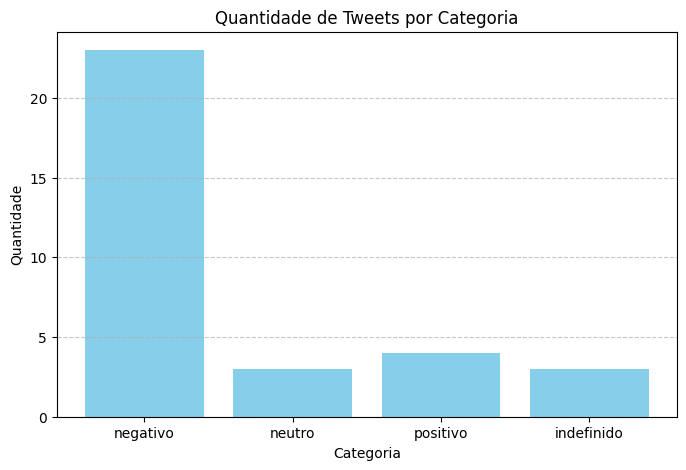

In [ ]:
contagem_categorias_1 = Counter(item["categoria"] for item in resultados_sentimentos_1)
desenhar_grafico_1(contagem_categorias_1)

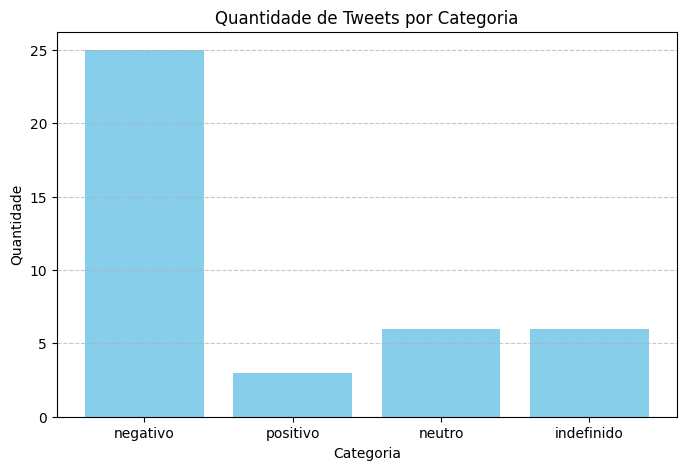

In [ ]:
contagem_categorias_2 = Counter(item["categoria"] for item in resultados_sentimentos_2)
desenhar_grafico_1(contagem_categorias_2)

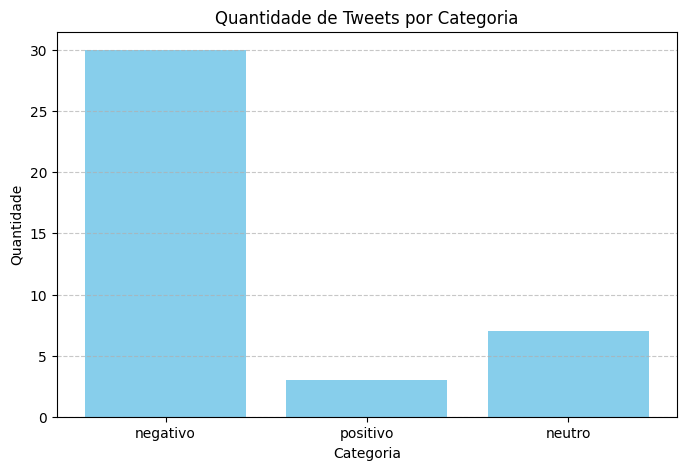

In [ ]:
contagem_categorias_3 = Counter(item["categoria"] for item in resultados_sentimentos_3)
desenhar_grafico_1(contagem_categorias_3)

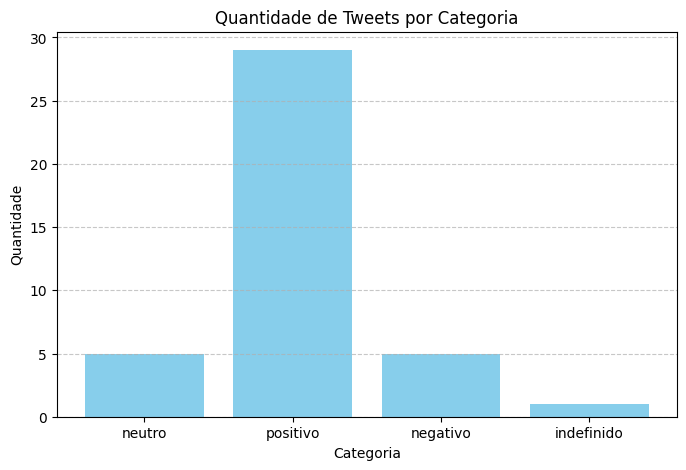

In [ ]:
contagem_categorias_4 = Counter(item["categoria"] for item in resultados_sentimentos_4)
desenhar_grafico_1(contagem_categorias_4)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain

def desenhar_grafico_2(resultados_sentimentos):
  # Substituir sentimento vazio por "indefinido"
  listas_de_sentimentos = [
      item["sentimentos"] if item["sentimentos"] else ["indefinido"]
      for item in resultados_sentimentos
  ]

  todos_sentimentos = list(chain.from_iterable(listas_de_sentimentos))

  contagem_sentimentos = Counter(todos_sentimentos)
  mais_comuns = contagem_sentimentos.most_common(10)

  # Remove "indefinido" do gráfico
  mais_comuns = [item for item in mais_comuns if item[0] != "indefinido"]

  if mais_comuns:
      labels, counts = zip(*mais_comuns)
      plt.figure(figsize=(10, 6))
      sns.barplot(x=counts, y=labels, palette="viridis")
      plt.title("Top 10 Sentimentos Mais Frequentes")
      plt.xlabel("Número de Tweets")
      plt.ylabel("Sentimento")
      plt.show()
  else:
      print("Não há sentimentos válidos para plotar.")

/tmp/ipython-input-2395048721.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


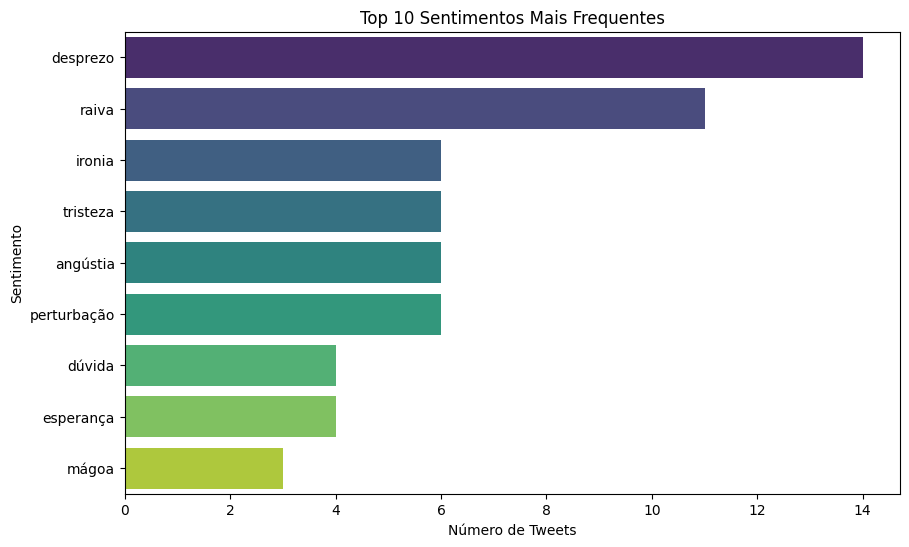

In [ ]:
desenhar_grafico_2(resultados_sentimentos_1)

/tmp/ipython-input-2395048721.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


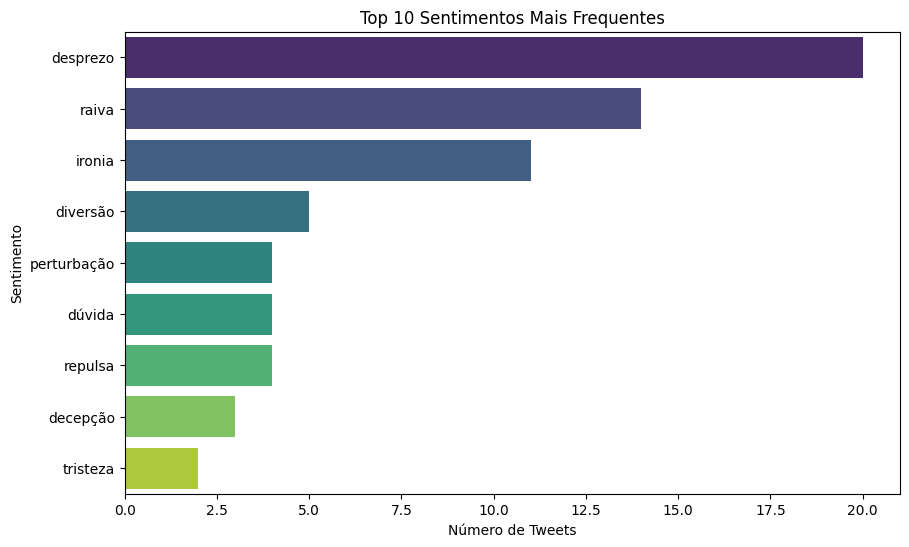

In [ ]:
desenhar_grafico_2(resultados_sentimentos_2)

/tmp/ipython-input-2395048721.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


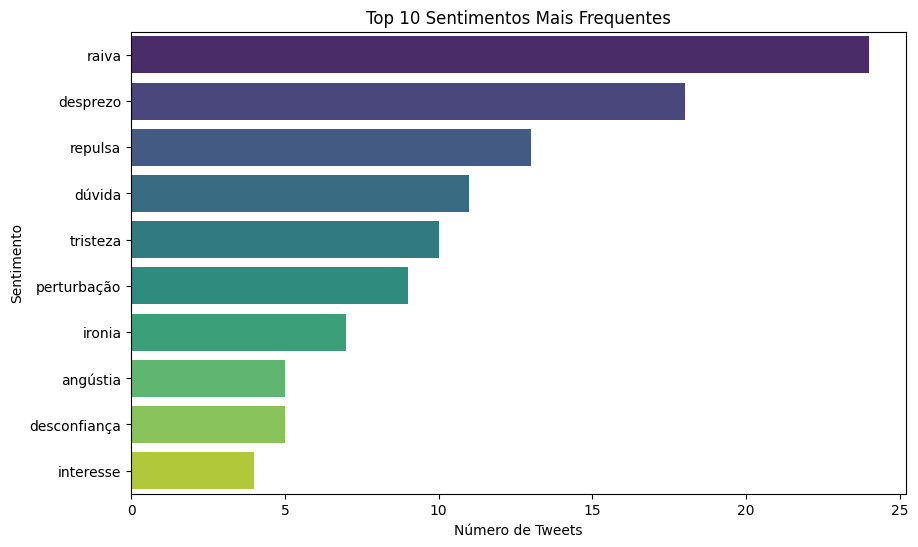

In [ ]:
desenhar_grafico_2(resultados_sentimentos_3)

/tmp/ipython-input-2395048721.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


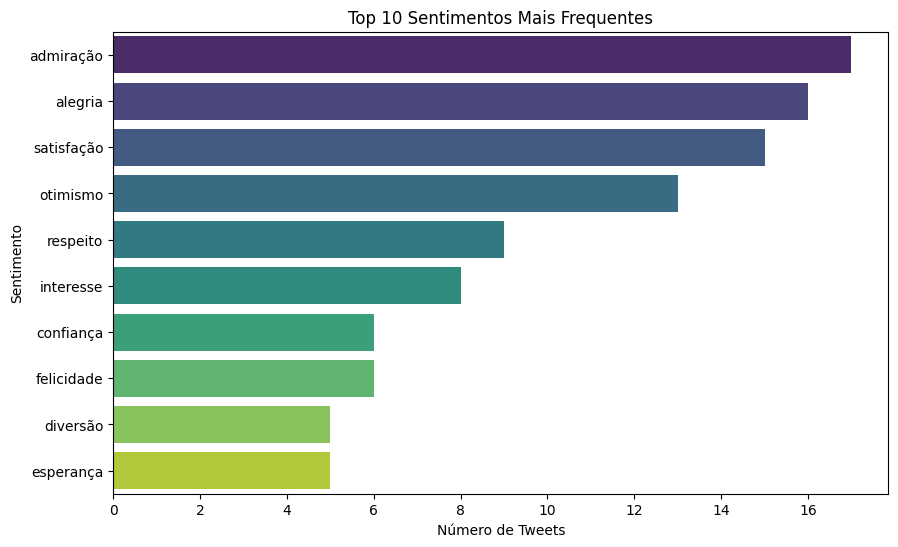

In [ ]:
desenhar_grafico_2(resultados_sentimentos_4)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def nuvem_palavras(resultados_sentimentos):
  text = ' '.join([' '.join(s) for s in [item["sentimentos"] for item in resultados_sentimentos if item["sentimentos"]]])
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title('Nuvem de Palavras dos Sentimentos')
  plt.show()


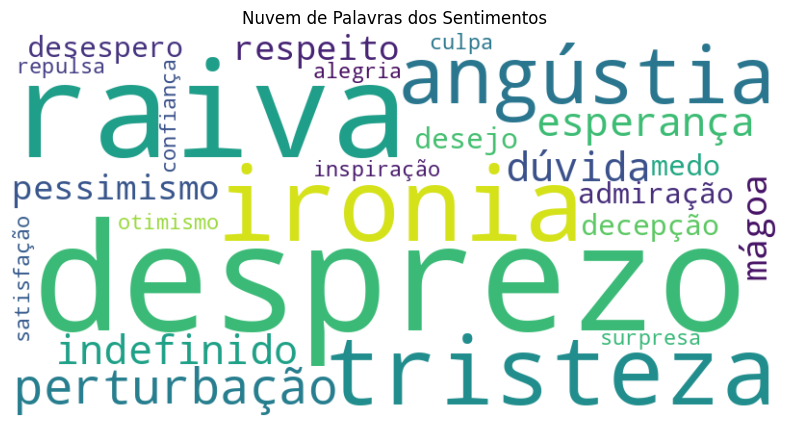

In [ ]:
nuvem_palavras(resultados_sentimentos_1)

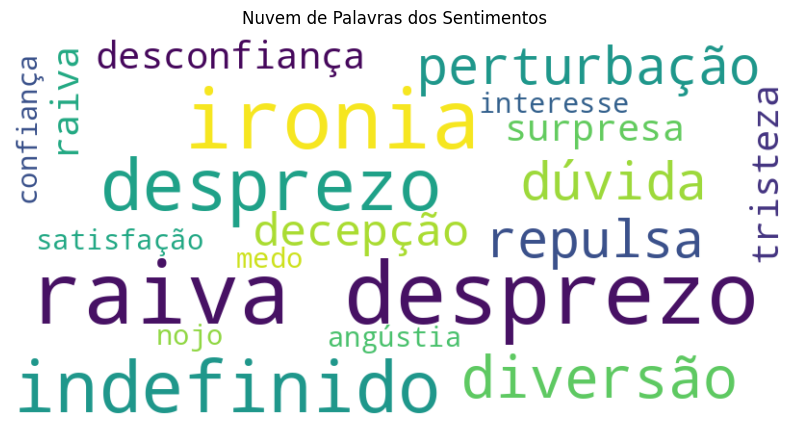

In [ ]:
nuvem_palavras(resultados_sentimentos_2)

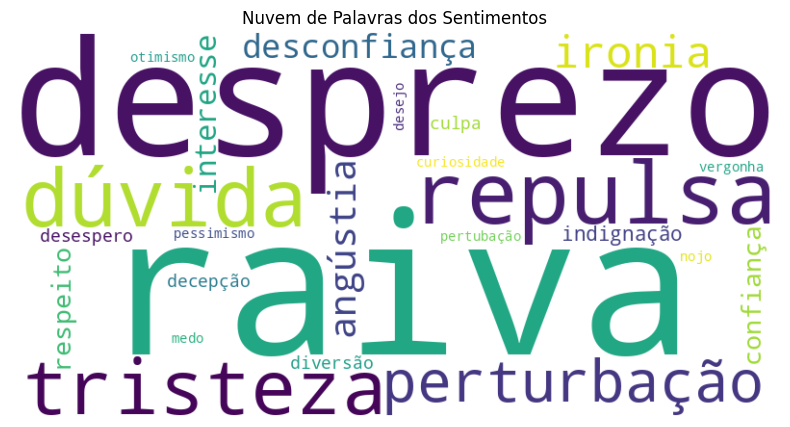

In [ ]:
nuvem_palavras(resultados_sentimentos_3)

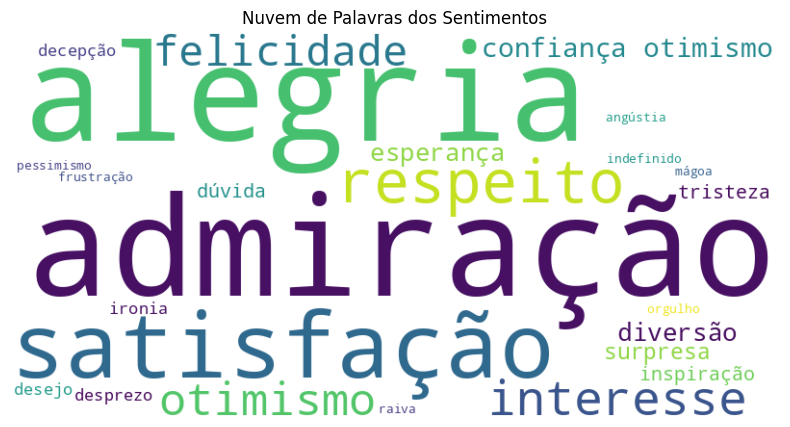

In [ ]:
nuvem_palavras(resultados_sentimentos_4)

In [ ]:
import pandas as pd
import seaborn as sns

def desenhar_grafico_3(resultados_sentimentos):
  # Montar dataframe para plot
  df = pd.DataFrame([
      {"categoria": item["categoria"], "sentimento": s}
      for item in resultados_sentimentos for s in item["sentimentos"]
  ])

  plt.figure(figsize=(12,6))
  sns.countplot(data=df, x='categoria', hue='sentimento')
  plt.xticks(rotation=0)
  plt.title("Distribuição dos Sentimentos por Categoria")
  plt.show()


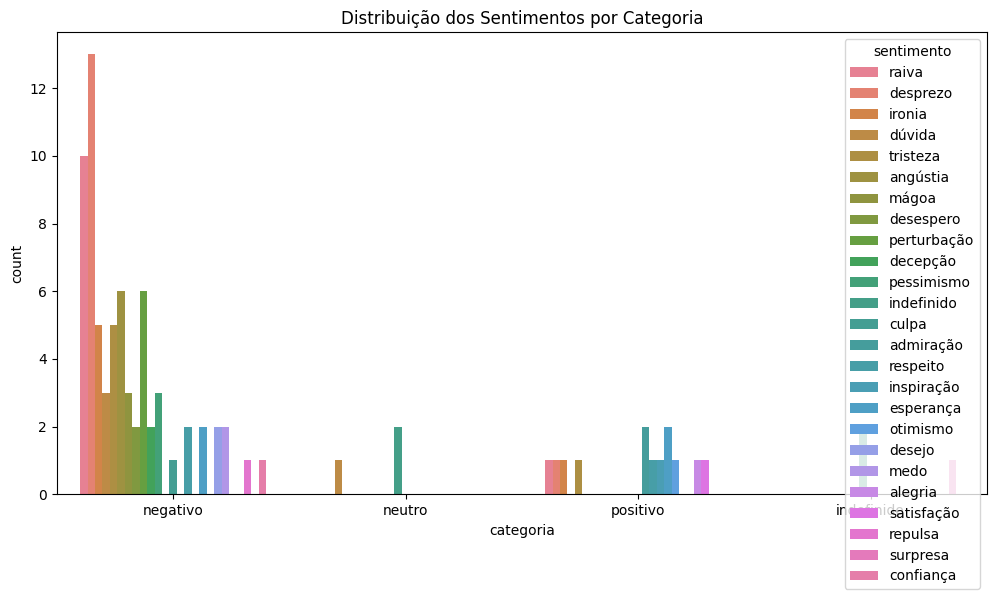

In [ ]:
desenhar_grafico_3(resultados_sentimentos_1)

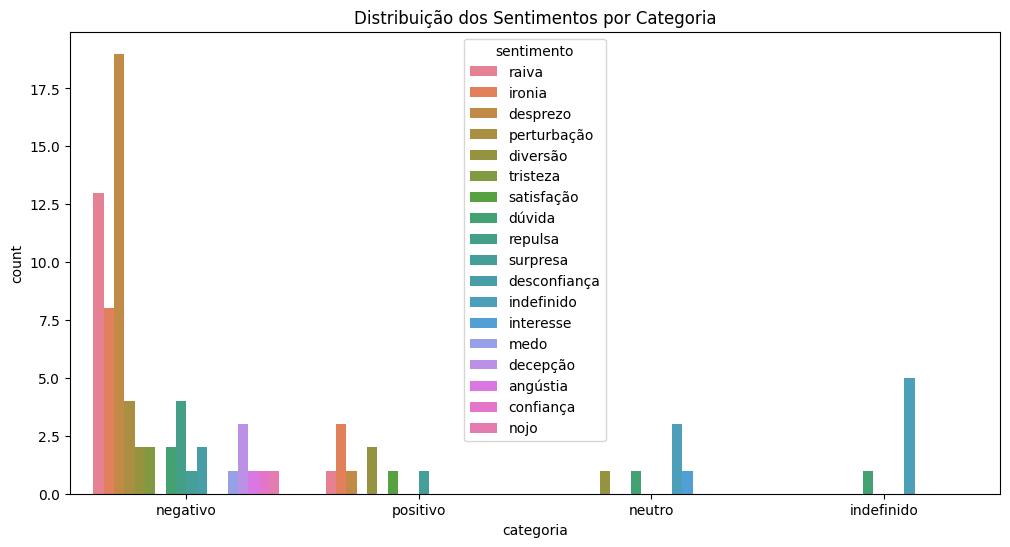

In [ ]:
desenhar_grafico_3(resultados_sentimentos_2)

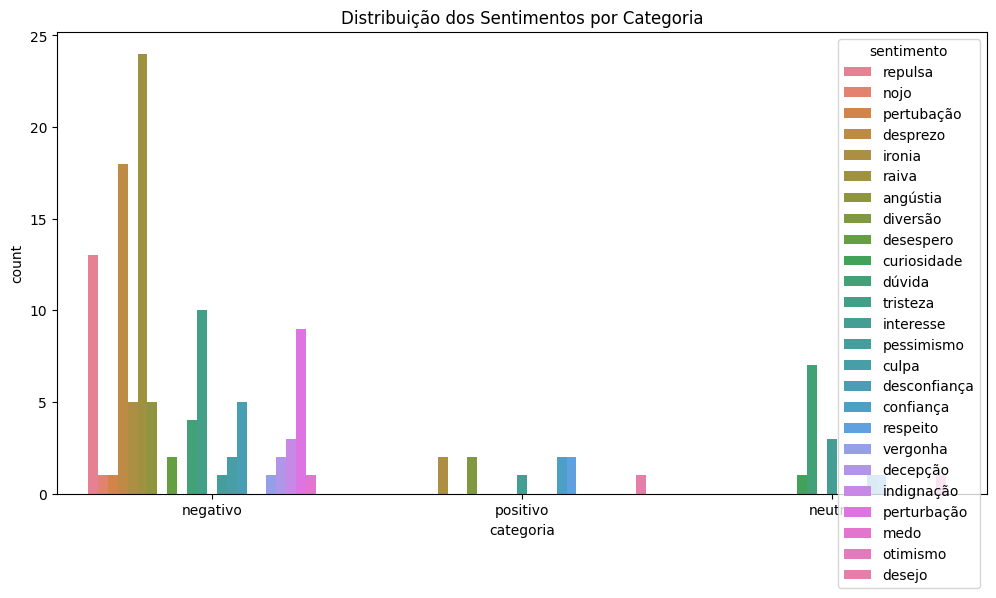

In [ ]:
desenhar_grafico_3(resultados_sentimentos_3)

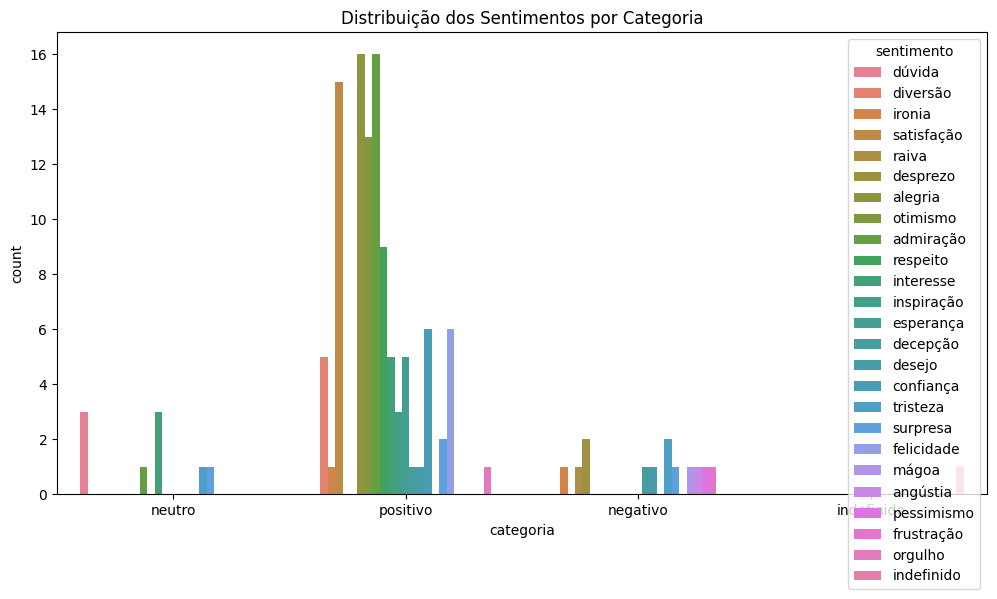

In [ ]:
desenhar_grafico_3(resultados_sentimentos_4)

# Capturando as contas mais populares do Brasil
Queremos extrair as contas mais populares no Brasil para fazer nossa análise.

Para isso, pegaremos o conteúdo de uma página que faz essa análise de quais são as contas mais populares do Brasil, e usaremos o Gemini para gerar a provável @username da conta descrita no texto, para que possamos extrair as informações da conta com a API do Twitter.

Os passos consistem no seguinte:
- Extrair o conteúdo em texto do site: "https://www.favikon.com/blog/top-x-influencers-brazil"
- Usar Gemini para gerar os supostos @userName dos ussuários descritos no texto
- Usar os @userName obtidos para buscar os seus Tweets mais recentes na API

In [ ]:
#@title Prompt usado no Gemini para capturar os nomes dos usuários a partir do conteúdo da página

from google.colab import userdata
from langchain_core.prompts import PromptTemplate

# Prompt para extrair nome + handle_x
template = (
    "Você é um assistente que extrai dados em JSON.\n"
    "A partir do TEXTO abaixo, extraia UMA LISTA JSON, sem texto antes ou depois.\n"
    "Cada item da lista deve ser um objeto com a chave EXATA: "
    '"nome".\n'
    "TEXTO:\n{conteudo_pagina}\n\n"
    "Responda SOMENTE com a lista JSON."
)

prompt = PromptTemplate.from_template(template)

In [ ]:
#@title Função para utilizar o prompt do Gemini no conteúdo da página fornecido, retornando os nomes dos usuários presentes nele

def extrair_contas_favikon(conteudo_pagina: str):
    mensagem = prompt.format(conteudo_pagina=conteudo_pagina)
    resposta = modelo.invoke(mensagem)
    texto = resposta.content if hasattr(resposta, "content") else resposta.text

    texto_limpo = texto.strip()
    texto_limpo = texto_limpo.removeprefix("```json").removeprefix("```")
    texto_limpo = texto_limpo.removesuffix("```")
    print(texto_limpo)

    try:
        dados = json.loads(texto_limpo)
    except json.JSONDecodeError:
        print("Falha ao fazer parse do JSON. Conteúdo bruto da resposta:")
        print(texto)
        return []

    if not isinstance(dados, list):
        print("Formato inesperado. Esperado: lista de objetos JSON.")
        print(dados)
        return []

    return dados

In [ ]:
#@title Converte o conteúdo da página HTML em string

import requests
from bs4 import BeautifulSoup

url = "https://www.favikon.com/blog/top-x-influencers-brazil"
resp = requests.get(url)
resp.raise_for_status()
html_str = resp.text

soup = BeautifulSoup(html_str, "html.parser")
texto_str = soup.get_text(separator="\n", strip=True)

print("Trecho do texto da página:")
print(texto_str[:1000])

Trecho do texto da página:
Top 20 X (Twitter) Influencers in Brazil in 2025 - Favikon
For brands
For brands
For creators
Products
Find
Make the right moves to spot the best creators for your brand
AI Search
Rankings
Radar
Lookalikes
Engage
Run campaigns, manage creators, and track results that tie back to you
Campaigns
Inbox
Contacts
Insights
Get the insights you need on any creator or brand, anytime, anywhere
Profile
Extension
Pricing
Resources
Blog & Articles
Your ultimate ressource for the creator economy
Methodology & Rankings
About Favikon, rankings, tools & much more.
Blog & Articles
Favikon V3 | The Future of Influencer Marketing Out Now
Favikon V3 is out now. Check what's new ->
10 LinkedIn Influencer Marketing Tips From Top Marketers
Many B2B marketers are unsure how to approach LinkedIn influencer marketing, from pricing posts to measuring ROI. This case study analyzes top campaigns and highlights 10 expert tips to help brands succeed with creators on LinkedIn.
The B2B Linked

In [ ]:
#@title Chamar o Gemini para extrair os nomes das contas citadas nos textos
contas = extrair_contas_favikon(texto_str)

nomes = [c.get("nome") for c in contas if c.get("nome")]
print(nomes)


[
  {
    "nome": "Felipe Neto"
  },
  {
    "nome": "Danilo Gentili"
  },
  {
    "nome": "Vinicios Betiol"
  },
  {
    "nome": "Maisa Silva"
  },
  {
    "nome": "Lorena Orsi"
  },
  {
    "nome": "Guilherme Gama"
  },
  {
    "nome": "Erika Hilton"
  },
  {
    "nome": "Eduardo Bolsonaro"
  },
  {
    "nome": "Tiago Santineli"
  },
  {
    "nome": "Whindersson Nunes"
  },
  {
    "nome": "Alvaro"
  },
  {
    "nome": "Leonardo Lucas"
  },
  {
    "nome": "Vinicius Jr."
  },
  {
    "nome": "Lucas"
  },
  {
    "nome": "Rafael Lange"
  },
  {
    "nome": "Rodrygo Goes"
  },
  {
    "nome": "Anitta"
  },
  {
    "nome": "Luiz Inácio Lula da Silva"
  },
  {
    "nome": "Nikolas Ferreira"
  },
  {
    "nome": "Neymar Jr"
  }
]

['Felipe Neto', 'Danilo Gentili', 'Vinicios Betiol', 'Maisa Silva', 'Lorena Orsi', 'Guilherme Gama', 'Erika Hilton', 'Eduardo Bolsonaro', 'Tiago Santineli', 'Whindersson Nunes', 'Alvaro', 'Leonardo Lucas', 'Vinicius Jr.', 'Lucas', 'Rafael Lange', 'Rodrygo Goes'

In [ ]:
#@title A partir da lista de nomes, usar um prompt Gemini para descobrir o @userName

prompt_usernames = PromptTemplate.from_template(
    "Você é um assistente que descobre arrobas de famosos no X (Twitter).\n"
    "Dado a lista de nomes abaixo, devolva SOMENTE um array JSON, sem texto extra.\n"
    "Cada item deve ter as chaves exatas: \"nome\" e \"username_x\".\n"
    "Use o @ exato que a pessoa usa no X, sem URL e sem @ (por exemplo: \"neymarjr\").\n"
    "Se não souber, use null em \"username_x\".\n\n"
    "NOMES:\n{lista_nomes}"
)

def sugerir_usernames_com_gemini(nomes):
    lista_nomes_str = "\n".join(nomes)
    mensagem = prompt_usernames.format(lista_nomes=lista_nomes_str)
    resp = modelo.invoke(mensagem)
    texto = resp.content if hasattr(resp, "content") else resp.text

    # se o modelo devolver com ```
    texto_limpo = texto.strip()
    texto_limpo = texto_limpo.removeprefix("```json").removeprefix("```")
    texto_limpo = texto_limpo.removesuffix("```").strip()

    try:
        dados = json.loads(texto_limpo)
    except json.JSONDecodeError:
        print("Falha ao fazer parse do JSON. Resposta bruta:")
        print(texto)
        return []

    if not isinstance(dados, list):
        print("Formato inesperado. Esperado lista JSON.")
        print(dados)
        return []

    return dados

In [ ]:
contas_sugeridas = sugerir_usernames_com_gemini(nomes)

print("Sugeridos pelo Gemini:")
for c in contas_sugeridas:
    print(c.get("nome"), "-", c.get("username_x"))

Sugeridos pelo Gemini:
Felipe Neto - felipeneto
Danilo Gentili - DaniloGentili
Vinicios Betiol - viniciosbetiol
Maisa Silva - maisa
Lorena Orsi - None
Guilherme Gama - None
Erika Hilton - ErikakHilton
Eduardo Bolsonaro - BolsonaroSP
Tiago Santineli - tiagosantineli
Whindersson Nunes - whindersson
Alvaro - None
Leonardo Lucas - None
Vinicius Jr. - vinijr
Lucas - None
Rafael Lange - cellbit
Rodrygo Goes - RodrygoGoes
Anitta - anitta
Luiz Inácio Lula da Silva - LulaOficial
Nikolas Ferreira - nikolas_dm
Neymar Jr - neymarjr


In [ ]:
import time
import requests

BASE_URL_INFO = "https://api.twitterapi.io/twitter/user/info"

def get_user_by_username(username: str, tentativas: int = 3, espera_inicial: float = 2.0):
    username = username.lstrip("@").strip()
    espera = espera_inicial

    for tentativa in range(1, tentativas + 1):
        params = {"userName": username}
        resp = requests.get(BASE_URL_INFO, headers=headers, params=params)

        # Sucesso
        if resp.status_code == 200:
            data = resp.json()
            user = data.get("data")
            if not user:
                print(f"Nenhum usuário retornado para '{username}'.")
                return None
            return user

        # Too Many Requests (free-tier: 1 req a cada 5s)
        if resp.status_code == 429:
            print(
                f"Erro 429 (Too Many Requests) ao buscar '{username}' "
                f"(tentativa {tentativa}/{tentativas}): {resp.text}"
            )
            # espera fixa de 5s, conforme mensagem da API
            if tentativa < tentativas:
                time.sleep(5)
                continue
            return None

        # Erro interno do servidor
        if resp.status_code == 500:
            print(
                f"Erro 500 ao buscar '{username}' (tentativa {tentativa}/{tentativas}): "
                f"{resp.text}"
            )
            if tentativa < tentativas:
                time.sleep(espera)
                espera *= 2
                continue
            return None

        # Outros erros (400, 401, 403, etc.) sem retry
        print(f"Erro {resp.status_code} ao buscar '{username}': {resp.text}")
        return None

    return None

In [ ]:
import time

def obter_ids_a_partir_de_sugestoes(contas_sugeridas):
    """
    contas_sugeridas: lista de dicts {nome, username_x} vinda do Gemini
    Respeita o limite free-tier: 1 request a cada 5 segundos.
    """
    resultados = []
    for conta in contas_sugeridas:
        nome = conta.get("nome")
        username_x = conta.get("username_x")

        if not username_x:
            resultados.append({
                "nome": nome,
                "username_x": None,
                "id": None,
                "validado": False,
            })
            continue

        # Pausa de 5 segundos entre requisições para evitar 429
        time.sleep(5)

        user = get_user_by_username(username_x)
        if user is None:
            resultados.append({
                "nome": nome,
                "username_x": username_x,
                "id": None,
                "validado": False,
            })
            continue

        resultados.append({
            "nome": nome,
            "username_x": user.get("userName", username_x.lstrip("@")),
            "id": user.get("id"),
            "validado": True,
            "name_api": user.get("name"),
        })

    return resultados

In [ ]:
contas_com_id = obter_ids_a_partir_de_sugestoes(contas_sugeridas)

print("\nResultado final (nome / @ / id / validado):")
for c in contas_com_id:
    print(c["nome"], "-", c["username_x"], "-", c["id"], "-", c["validado"])


Resultado final (nome / @ / id / validado):
Felipe Neto - felipeneto - 14128609 - True
Danilo Gentili - DaniloGentili - 14213711 - True
Vinicios Betiol - ViniciosBetiol - 115678425 - True
Maisa Silva - maisa - 2203709322 - True
Lorena Orsi - None - None - False
Guilherme Gama - None - None - False
Erika Hilton - ErikakHilton - 738143559920934912 - True
Eduardo Bolsonaro - BolsonaroSP - 74756085 - True
Tiago Santineli - tiagosantineli - 215282625 - True
Whindersson Nunes - whindersson - 230186518 - True
Alvaro - None - None - False
Leonardo Lucas - None - None - False
Vinicius Jr. - vinijr - 2329070186 - True
Lucas - None - None - False
Rafael Lange - cellbit - 451200058 - True
Rodrygo Goes - RodrygoGoes - 815671379202887684 - True
Anitta - Anitta - 141817380 - True
Luiz Inácio Lula da Silva - LulaOficial - 2670726740 - True
Nikolas Ferreira - nikolas_dm - 758264276 - True
Neymar Jr - neymarjr - 158487331 - True


In [ ]:
BASE_URL_LAST_TWEETS = "https://api.twitterapi.io/twitter/user/last_tweets"

def coletar_textos_tweets_por_user_id(user_id):
    """
    Retorna uma lista de dicts {"text": "..."} para um único userId.
    NÃO faz retry interno de 429; assume que o chamador controla o intervalo.
    """
    uid_str = str(user_id)
    print(f"Buscando tweets para userId {uid_str}...")

    params = {"userId": uid_str}
    resp = requests.get(BASE_URL_LAST_TWEETS, headers=headers, params=params)

    print("Status code:", resp.status_code)
    print("Resposta bruta (início):")
    print(resp.text[:200])

    if resp.status_code == 429:
        print("Erro 429 (Too Many Requests). Chamadas estão muito rápidas.")
        return []

    if resp.status_code != 200:
        print(f"Erro {resp.status_code} para {uid_str}: {resp.text}")
        return []

    data = resp.json()
    bloco_data = data.get("data")
    if not bloco_data:
        print(f"Nenhum dado de tweets para userId {uid_str}: {data.get('msg')}")
        return []

    tweets = bloco_data.get("tweets", [])
    textos = []

    for t in tweets:
        if isinstance(t, dict):
            texto = t.get("text")
            if texto:
                textos.append({"text": texto})

    return textos

In [ ]:
# Extrair apenas os userId válidos (não None)
def extrair_user_ids(contas_com_id):
    user_ids = []
    for c in contas_com_id:
        uid = c.get("id")
        if uid:  # ignora None ou vazio
            user_ids.append(uid)
    return user_ids

user_ids = extrair_user_ids(contas_com_id)

print("UserIds válidos:")
for uid in user_ids:
    print(uid)

UserIds válidos:
14128609
14213711
115678425
2203709322
738143559920934912
74756085
215282625
230186518
2329070186
451200058
815671379202887684
141817380
2670726740
758264276
158487331


In [ ]:
def coletar_e_salvar_varios_users(user_ids):
    for uid in user_ids:
        tweets_textos = coletar_textos_tweets_por_user_id(uid)
        print(f"Total de tweets salvos para {uid}: {len(tweets_textos)}")

        # salvar_json é sua função já existente
        salvar_json(tweets_textos, sufixo=f"user_{uid}")

        # pausa de 5+ segundos para não disparar 429 no próximo user
        print("Aguardando 5 segundos antes do próximo userId...")
        time.sleep(5)

coletar_e_salvar_varios_users(user_ids)

Buscando tweets para userId 14128609...
Status code: 200
Resposta bruta (início):
{"status":"success","code":0,"msg":"success","data":{"pin_tweet":null,"tweets":[{"type":"tweet","id":"1993348432845849012","url":"https://x.com/felipeneto/status/1993348432845849012","twitterUrl":"htt
Total de tweets salvos para 14128609: 18
Aguardando 5 segundos antes do próximo userId...
Buscando tweets para userId 14213711...
Status code: 200
Resposta bruta (início):
{"status":"success","code":0,"msg":"success","data":{"pin_tweet":null,"tweets":[{"type":"tweet","id":"1992754128846528922","url":"https://x.com/DaniloGentili/status/1992754128846528922","twitterUrl":"
Total de tweets salvos para 14213711: 19
Aguardando 5 segundos antes do próximo userId...
Buscando tweets para userId 115678425...
Status code: 200
Resposta bruta (início):
{"status":"success","code":0,"msg":"success","data":{"pin_tweet":null,"tweets":[]},"has_next_page":false,"next_cursor":"DAADDAABAAgAAgAAAAIIAAMAAAAACAAEAAAAAAoABRuqNSh4wCc

In [ ]:
#@title Definição das listas com os textos que serão usadas para análise de sentimentos

# Uma lista separada para cada userId (se quiser separar por conta)
todas_listas = {}

for uid in user_ids:
    lista_textos = []
    sufixo = f"user_{uid}"          # mesmo sufixo usado em salvar_json
    carregar_json(lista_textos, sufixo)
    # lista_textos agora contém [{"text": "..."}] ou só strings,
    # dependendo de como você salvou

    # Se o JSON foi salvo como [{"text": "..."}, ...], converta para lista de strings:
    if lista_textos and isinstance(lista_textos[0], dict):
        textos_puros = [t.get("text", "") for t in lista_textos if t.get("text")]
    else:
        textos_puros = [str(t) for t in lista_textos]

    todas_listas[uid] = textos_puros

    print(f"\nTweets carregados para userId {uid}:")
    imprimir_lista(textos_puros)  # imprime cada texto

# Se quiser juntar tudo em uma única lista para análise de sentimento:
all_texts_gemini = []
for uid, textos in todas_listas.items():
    all_texts_gemini.extend(textos)


Tweets carregados para userId 14128609:
Quantidade total de tweets: 18
Tweet 1: 🌃 CIDADE DORME VIROU JOGO!

A pré-venda de Cidade Dorme Netolab ESTÁ ABERTA e você não pode perder a oportunidade de ter o jogo físico na sua casa. Compre agora na promoção e ganhe duas cartas exclusivas!

🔗 Link: https://t.co/R53BVvTbCZ

Tweet 2: O vídeo de hoje é uma volta às origens do canal!

Quem lembra do “Tente Não Rir” e do “APEI”?

Então…

Assista: https://t.co/iSl2bKhDmV https://t.co/9UkTlsnS6J

Tweet 3: Pra quem pergunta pq eu parei de usar o Twitter pra dar opinião…

Repostei um texto do mais respeitado crítico de cinema do Brasil, dizendo q concordo com sua visão sobre o filme “Frankenstein”.

Tive q ler um desgraçado responder com “Frankenstein é um livro medíocre e vcs só querem pagar de intelectuais”.

Livro medíocre. O livro que inventou a ficção científica. O livro q mudou a literatura. O livro q 200 anos depois continua sendo um dos melhores já escritos, extremamente atual e maravilhoso.

In [ ]:
#@title Processando cada tweet

resultados_sentimentos = []
processando_tweets(all_texts_gemini, resultados_sentimentos)

In [ ]:
print(resultados_sentimentos)

[{'tweet': '🌃 CIDADE DORME VIROU JOGO!\n\nA pré-venda de Cidade Dorme Netolab ESTÁ ABERTA e você não pode perder a oportunidade de ter o jogo físico na sua casa. Compre agora na promoção e ganhe duas cartas exclusivas!\n\n🔗 Link: https://t.co/R53BVvTbCZ', 'categoria': 'positivo', 'sentimentos': ['felicidade', 'interesse', 'otimismo', 'desejo']}, {'tweet': 'O vídeo de hoje é uma volta às origens do canal!\n\nQuem lembra do “Tente Não Rir” e do “APEI”?\n\nEntão…\n\nAssista: https://t.co/iSl2bKhDmV https://t.co/9UkTlsnS6J', 'categoria': 'positivo', 'sentimentos': ['felicidade', 'alegria', 'interesse', 'diversão', 'otimismo', 'desejo']}, {'tweet': 'Pra quem pergunta pq eu parei de usar o Twitter pra dar opinião…\n\nRepostei um texto do mais respeitado crítico de cinema do Brasil, dizendo q concordo com sua visão sobre o filme “Frankenstein”.\n\nTive q ler um desgraçado responder com “Frankenstein é um livro medíocre e vcs só querem pagar de intelectuais”.\n\nLivro medíocre. O livro que inv

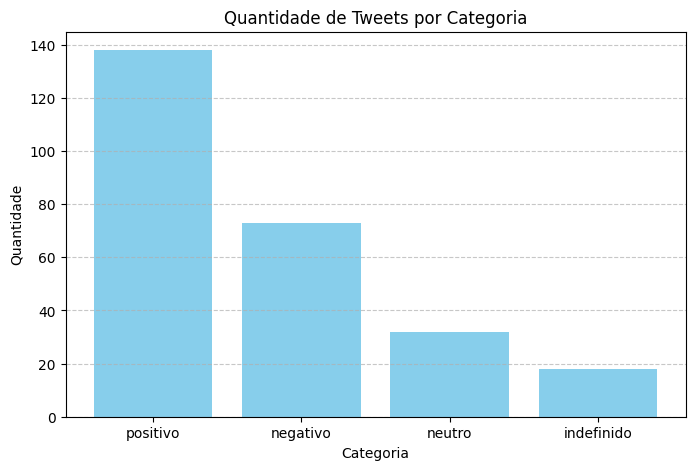

In [ ]:
contagem_categorias = Counter(item["categoria"] for item in resultados_sentimentos)
desenhar_grafico_1(contagem_categorias)

/tmp/ipython-input-2395048721.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


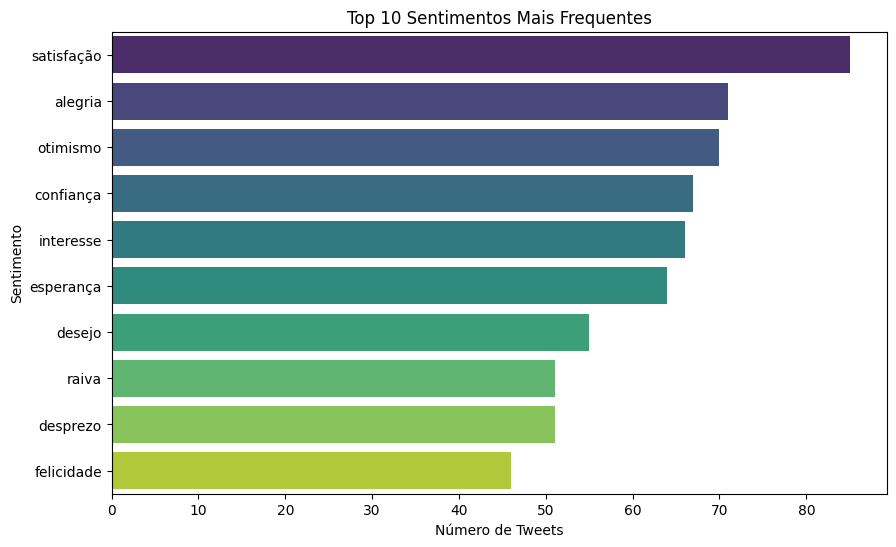

In [ ]:
desenhar_grafico_2(resultados_sentimentos)

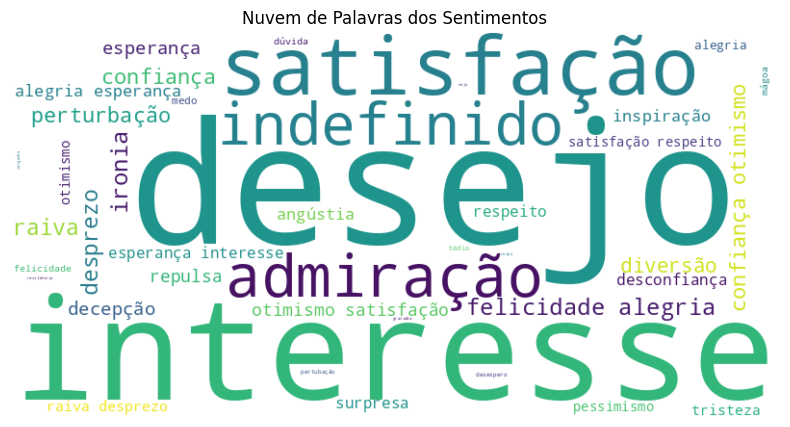

In [ ]:
nuvem_palavras(resultados_sentimentos)

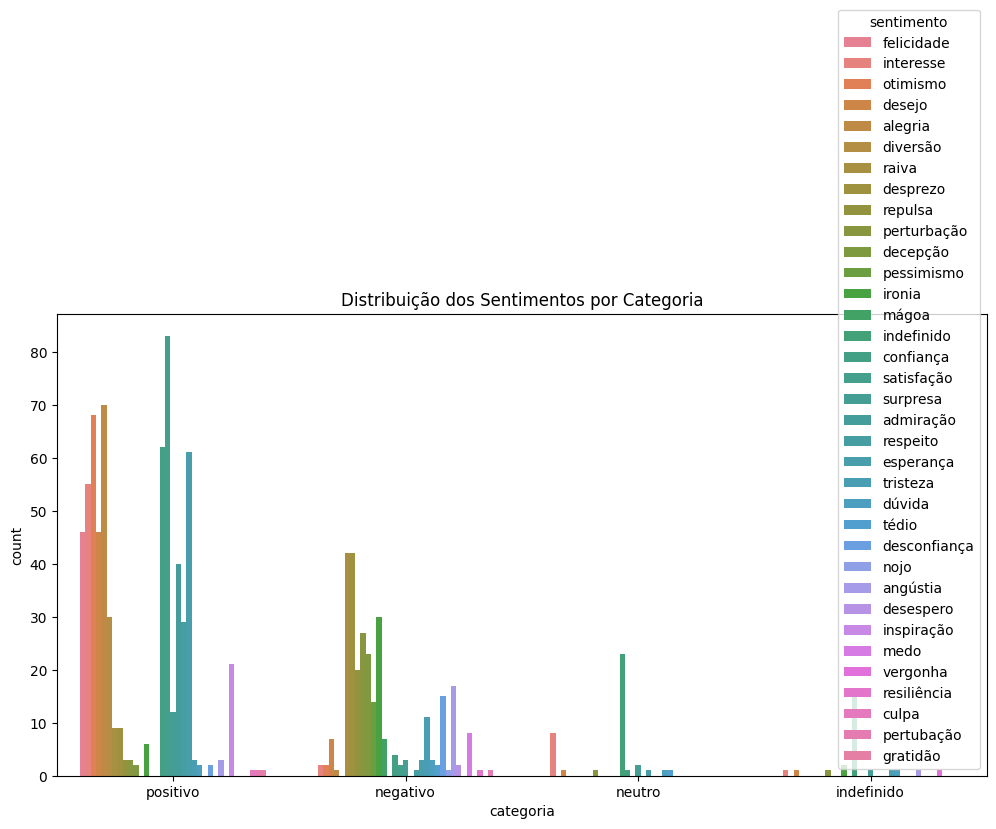

In [ ]:
desenhar_grafico_3(resultados_sentimentos)